In [2257]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# <center> <span style="color:teal; font-size:50px;"> Loading Data and Preview </span>

In [2258]:
items_df = pd.read_csv('items.csv')
customers_df = pd.read_csv('customers.csv')
orders_df = pd.read_csv('orders.csv')
order_items_df = pd.read_csv('order_item.csv')


print("=== ITEMS ===")
print(items_df.shape)
print(items_df.isnull().sum())

print("\n=== CUSTOMERS ===")
print(customers_df.shape)
print(customers_df.isnull().sum())

print("\n=== ORDERS ===")
print(orders_df.shape)
print(orders_df.isnull().sum())

print("\n=== ORDER_ITEMS ===")
print(order_items_df.shape)
print(order_items_df.isnull().sum())


=== ITEMS ===
(50, 7)
id                   0
item_name            0
item_category        8
item_price           0
stock_quantity       5
item_brand           3
item_availability    0
dtype: int64

=== CUSTOMERS ===
(500, 9)
id               0
first_name       0
last_name        0
gender          53
age             25
nationallity     0
joining_date    61
phone_number     0
email            0
dtype: int64

=== ORDERS ===
(600, 7)
order_id             0
customer_id         45
delivery_address     0
delivery_days       75
order_date           0
payment_method       0
order_source         0
dtype: int64

=== ORDER_ITEMS ===
(1000, 5)
Unnamed: 0     0
id             0
order_id       0
item_id       40
quantity       0
dtype: int64


# <center> <span style="color:teal; font-size:50px;"> Data Preparation </span>


In [2259]:
items = items_df.copy()
customers = customers_df.copy()
orders = orders_df.copy()
order_items = order_items_df.copy()


#### <span style="color:tomato; font-size:25px;"> Handle Duplicate Data in Items Dataset </span>

In [2260]:

# Dup 1: same item_name + same item_brand
dupes_num1 = items[items.duplicated(subset=['item_name', 'item_brand'], keep=False)]
print("Dup 1 (same name + same brand):")
print(dupes_num1[['id', 'item_name', 'item_brand']])

# Dup 2: same item_name, one row has brand and one does not
dupes_num2 = items[items.duplicated(subset=['item_name'], keep=False)]
print("\nDup 2 (same name, check brand):")
print(dupes_num2[['id', 'item_name', 'item_brand']])

Dup 1 (same name + same brand):
Empty DataFrame
Columns: [id, item_name, item_brand]
Index: []

Dup 2 (same name, check brand):
    id   item_name item_brand
0    1  Television        JBL
1    2      Laptop         HP
2    3     Desktop         HP
3    4  Smartphone       Bose
4    5      Tablet    Toshiba
5    6     Printer       Sony
6    7      Camera  Microsoft
7    8   Headphone        NaN
8    9     Speaker    Toshiba
41  42  Television    Samsung
42  43      Laptop       Dell
43  44     Desktop        JBL
44  45  Smartphone  Panasonic
45  46      Tablet         HP
46  47     Printer    Toshiba
47  48      Camera  Panasonic
48  49   Headphone       Sony
49  50     Speaker   Logitech


#### <span style="color:tomato; font-size:25px;"> Remove Duplicates </span>

In [2261]:
# Update associations in order_items before removing
order_items.loc[order_items['item_id'] == 8, 'item_id'] = 49

# Remove the duplicate row
items = items[items['id'] != 8].reset_index(drop=True)

print(f"Items shape after dedup: {items.shape}")

Items shape after dedup: (49, 7)


#### <span style="color:tomato; font-size:25px;"> Handle Duplicate Data in Customers Dataset </span>

In [2262]:
dupes_email = customers[customers.duplicated(subset='email', keep=False)]
print("Duplicate customers by email:")
print(dupes_email[['id', 'first_name', 'last_name', 'email']])

Duplicate customers by email:
Empty DataFrame
Columns: [id, first_name, last_name, email]
Index: []


#### <span style="color:tomato; font-size:25px;"> Check Missing Data Precentages </span>

In [2263]:
print("=== ITEMS missing % ===")
print((items_df.isnull().sum() / len(items_df) * 100).round(2))

print("\n=== CUSTOMERS missing % ===")
print((customers_df.isnull().sum() / len(customers_df) * 100).round(2))

print("\n=== ORDERS missing % ===")
print((orders_df.isnull().sum() / len(orders_df) * 100).round(2))

print("\n=== ORDER_ITEMS missing % ===")
print((order_items_df.isnull().sum() / len(order_items_df) * 100).round(2))

=== ITEMS missing % ===
id                    0.0
item_name             0.0
item_category        16.0
item_price            0.0
stock_quantity       10.0
item_brand            6.0
item_availability     0.0
dtype: float64

=== CUSTOMERS missing % ===
id               0.0
first_name       0.0
last_name        0.0
gender          10.6
age              5.0
nationallity     0.0
joining_date    12.2
phone_number     0.0
email            0.0
dtype: float64

=== ORDERS missing % ===
order_id             0.0
customer_id          7.5
delivery_address     0.0
delivery_days       12.5
order_date           0.0
payment_method       0.0
order_source         0.0
dtype: float64

=== ORDER_ITEMS missing % ===
Unnamed: 0    0.0
id            0.0
order_id      0.0
item_id       4.0
quantity      0.0
dtype: float64


#### <span style="color:tomato; font-size:25px;"> Handle missing data </span>

In [2264]:
# --- ITEMS ---

items['item_category'] = items['item_category'].fillna('Unknown')
items['stock_quantity'] = items['stock_quantity'].fillna(items['stock_quantity'].median())
items['item_brand'] = items['item_brand'].fillna('Unknown')

print("Items missing after fix:")
print(items.isnull().sum())

# --- CUSTOMERS ---

customers['gender'] = customers['gender'].fillna('Unknown')
customers['age'] = customers['age'].fillna(customers['age'].mean())
customers['joining_date'] = customers['joining_date'].fillna('2020-01-01')

print("\nCustomers missing after fix:")
print(customers.isnull().sum())
print(f"Customers shape: {customers.shape}")

# --- ORDERS ---

orders = orders[orders['customer_id'].notna()].reset_index(drop=True)
orders['delivery_days'] = orders['delivery_days'].fillna(orders['delivery_days'].median())

print("\nOrders missing after fix:")
print(orders.isnull().sum())
print(f"Orders shape: {orders.shape}")

# --- ORDER_ITEMS ---

order_items = order_items[order_items['item_id'].notna()].reset_index(drop=True)

print("\nOrder_items missing after fix:")
print(order_items.isnull().sum())
print(f"Order_items shape: {order_items.shape}")

Items missing after fix:
id                   0
item_name            0
item_category        0
item_price           0
stock_quantity       0
item_brand           0
item_availability    0
dtype: int64

Customers missing after fix:
id              0
first_name      0
last_name       0
gender          0
age             0
nationallity    0
joining_date    0
phone_number    0
email           0
dtype: int64
Customers shape: (500, 9)

Orders missing after fix:
order_id            0
customer_id         0
delivery_address    0
delivery_days       0
order_date          0
payment_method      0
order_source        0
dtype: int64
Orders shape: (555, 7)

Order_items missing after fix:
Unnamed: 0    0
id            0
order_id      0
item_id       0
quantity      0
dtype: int64
Order_items shape: (960, 5)


# <center> <span style="color:teal; font-size:50px;"> Data Analysis </span>

##### <span style="color:tomato; font-size:25px;"> 1a: Count customers by gender + bar chart </span>

In [2265]:
gender_counts = customers.groupby('gender')['id'].count().reset_index()
gender_counts.columns = ['gender', 'customer_count']
print(gender_counts)

        gender  customer_count
0      Agender              13
1     Bigender               5
2       Female             203
3  Genderfluid              12
4  Genderqueer               5
5         Male             196
6   Non-binary               7
7   Polygender               6
8      Unknown              53


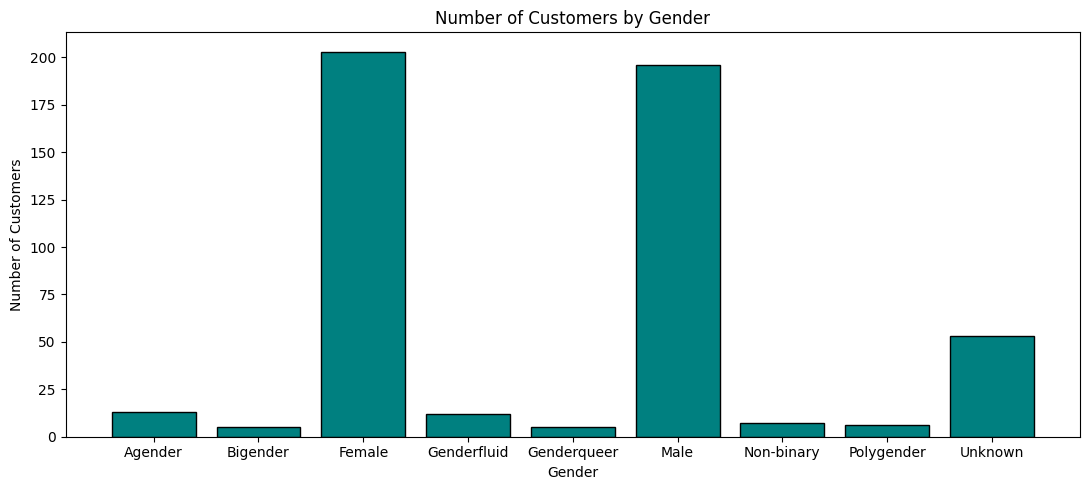

In [2266]:
plt.figure(figsize=(11, 5))
plt.bar(gender_counts['gender'], gender_counts['customer_count'], color='teal', edgecolor='black')
plt.title('Number of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

#### <span style="color:tomato; font-size:25px;"> 1b: Customer age distribution </span>

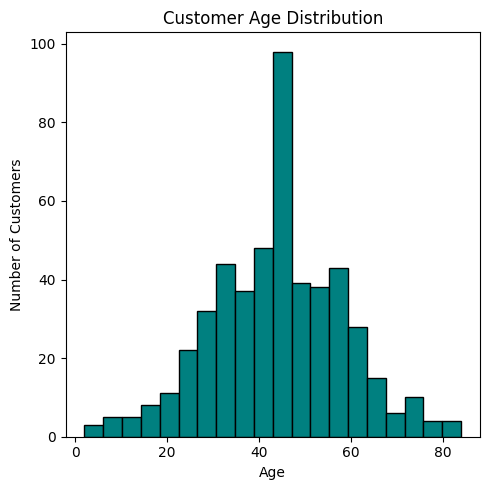

In [2267]:
plt.figure(figsize=(5, 5))
plt.hist(customers['age'], bins=20, color='teal', edgecolor='black')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

##### <span style="color:tomato; font-size:25px;"> 1c: Year with most joining customers </span>

In [2268]:

# Extract year from joining_date
customers['joining_year'] = pd.to_datetime(customers['joining_date']).dt.year

# Count customers per year
year_counts = customers.groupby('joining_year')['id'].count().reset_index()
year_counts.columns = ['year', 'customer_count']
print(year_counts)

# Year with most customers
best_year = year_counts.loc[year_counts['customer_count'].idxmax()]
print(f"\nYear with most joining customers: {int(best_year['year'])} ({int(best_year['customer_count'])} customers)")

   year  customer_count
0  2020             199
1  2021             138
2  2022             163

Year with most joining customers: 2020 (199 customers)


##### <span style="color:tomato; font-size:25px;"> 1d: Trend in customer joining 2020-2023 </span>

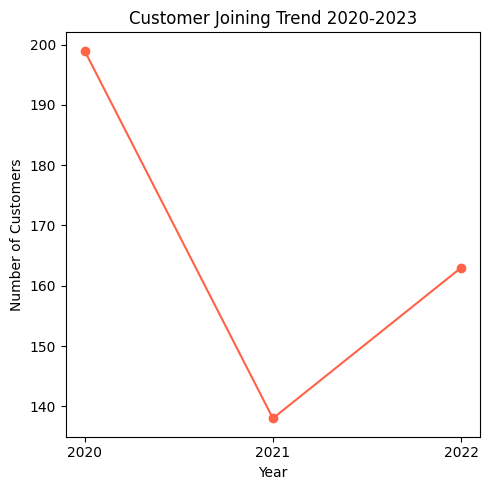

   year  customer_count
0  2020             199
1  2021             138
2  2022             163

Conclusion: The trend is not consistent - customers peaked in 2020 (199),
dropped in 2021 (138), then slightly recovered in 2022 (163).
This suggests a sporadic/unpredictable pattern rather than a consistent trend.


In [2269]:

plt.figure(figsize=(5, 5))
plt.plot(year_counts['year'], year_counts['customer_count'], marker='o', color='tomato')
plt.title('Customer Joining Trend 2020-2023')
plt.xlabel('Year')
plt.ylabel('Number of Customers')
plt.xticks(year_counts['year'])
plt.tight_layout()
plt.show()

print(year_counts)
print("\nConclusion: The trend is not consistent - customers peaked in 2020 (199),")
print("dropped in 2021 (138), then slightly recovered in 2022 (163).")
print("This suggests a sporadic/unpredictable pattern rather than a consistent trend.")

##### <span style="color:tomato; font-size:25px;"> 1e: Seasonality in customer joining by month </span>

    month  customer_count month_name
0       1              90    January
1       2              43   February
2       3              30      March
3       4              34      April
4       5              40        May
5       6              34       June
6       7              29       July
7       8              48     August
8       9              34  September
9      10              36    October
10     11              31   November
11     12              51   December

Month with most joining customers: January (90 customers)


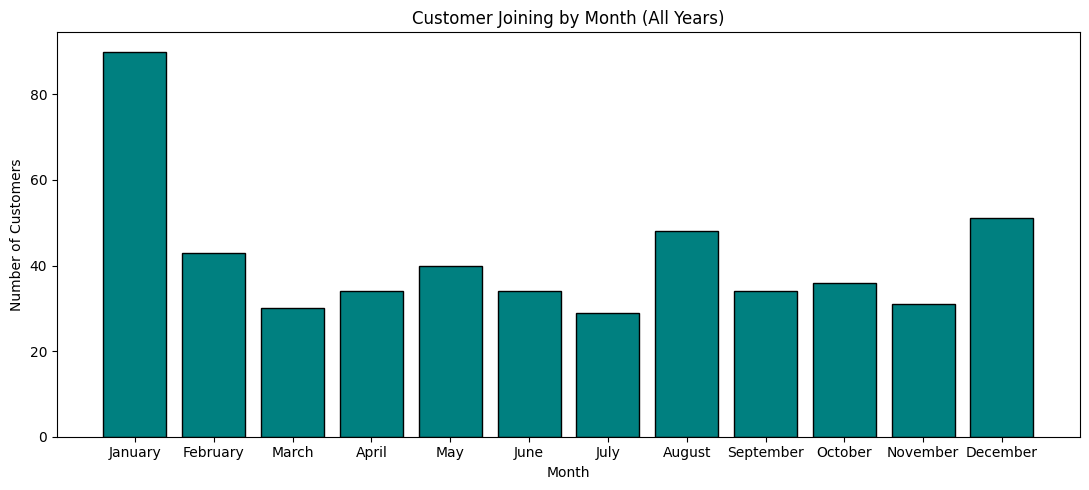

In [2270]:

customers['joining_month'] = pd.to_datetime(customers['joining_date']).dt.month

month_counts = customers.groupby('joining_month')['id'].count().reset_index()
month_counts.columns = ['month', 'customer_count']

month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}
month_counts['month_name'] = month_counts['month'].map(month_names)

print(month_counts)

best_month = month_counts.loc[month_counts['customer_count'].idxmax()]
print(f"\nMonth with most joining customers: {best_month['month_name']} ({int(best_month['customer_count'])} customers)")

plt.figure(figsize=(11, 5))
plt.bar(month_counts['month_name'], month_counts['customer_count'], color='teal', edgecolor='black')
plt.title('Customer Joining by Month (All Years)')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

##### <span style="color:tomato; font-size:25px;"> 2a: Count items by category </span>

                          category  item_count
0                  Audio Equipment           3
1                           Cables           1
2        Computers and Accessories           8
3                 Gaming Equipment           2
4   Mobile Devices and Accessories           7
5                Network Equipment           1
6            Photography Equipment           6
7    Printers and Office Equipment           6
8                         Software           1
9                  Storage Devices           1
10        Televisions and Displays           4
11                         Unknown           7
12     Video Players and Recorders           2


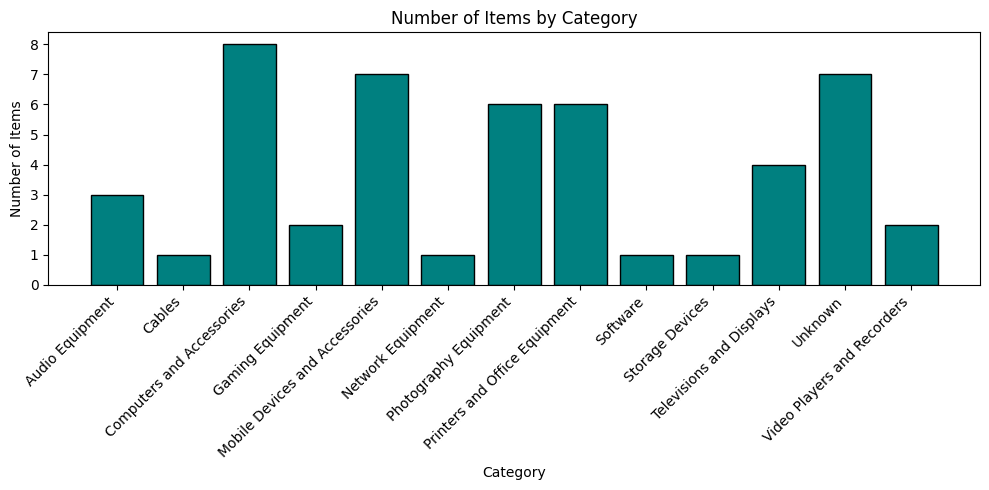

In [2271]:

category_counts = items.groupby('item_category')['id'].count().reset_index()
category_counts.columns = ['category', 'item_count']
print(category_counts)

plt.figure(figsize=(10, 5))
plt.bar(category_counts['category'], category_counts['item_count'], color='teal', edgecolor='black')
plt.title('Number of Items by Category')
plt.xlabel('Category')
plt.ylabel('Number of Items')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### <span style="color:tomato; font-size:25px;"> 2b: Item with largest and lowest quantity in stock </span>

In [2272]:
missing_stock_ids = items_df[items_df['stock_quantity'].isna()]['id'].tolist()
print(f"Items excluded (had missing stock_quantity): {missing_stock_ids}")

items_stock = items[~items['id'].isin(missing_stock_ids)]

max_stock = items_stock.loc[items_stock['stock_quantity'].idxmax()]
min_stock = items_stock.loc[items_stock['stock_quantity'].idxmin()]

result = pd.DataFrame([max_stock, min_stock])[['id', 'item_name', 'item_brand', 'stock_quantity']]
result.index = ['Largest Stock', 'Lowest Stock']
print(result)

Items excluded (had missing stock_quantity): [19, 26, 28, 37, 49]
               id     item_name item_brand  stock_quantity
Largest Stock  41    VR Headset        JBL          1367.0
Lowest Stock   35  Wi-Fi Router  Microsoft            14.0


##### <span style="color:tomato; font-size:25px;"> 2c: Mean quantity in stock </span>

In [2273]:
mean_stock = items_stock['stock_quantity'].mean()
print(f"Mean stock quantity (excluding items with missing stock): {mean_stock:.2f}")
max_price = items_stock['item_price'].max()
min_price = items_stock['item_price'].min()



Mean stock quantity (excluding items with missing stock): 746.43


##### <span style="color:tomato; font-size:25px;"> 3a: Count purchases per customer </span>

   number_of_purchases  number_of_customers
0                    1                  162
1                    2                  103
2                    3                   47
3                    4                    9
4                    5                    2


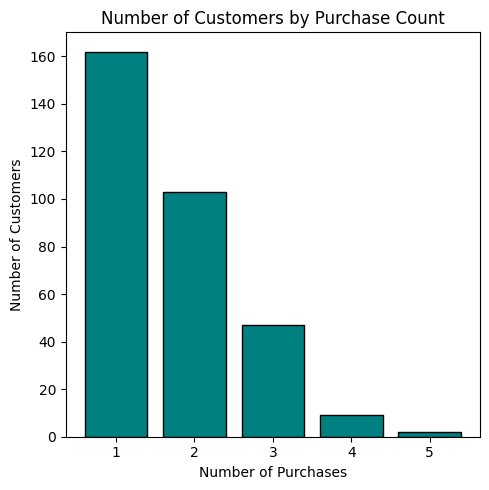

In [2274]:

orders_per_customer = orders.groupby('customer_id')['order_id'].count().reset_index()
orders_per_customer.columns = ['customer_id', 'order_count']

purchase_distribution = orders_per_customer.groupby('order_count')['customer_id'].count().reset_index()
purchase_distribution.columns = ['number_of_purchases', 'number_of_customers']
print(purchase_distribution)

plt.figure(figsize=(5, 5))
plt.bar(purchase_distribution['number_of_purchases'], purchase_distribution['number_of_customers'], color='teal', edgecolor='black')
plt.title('Number of Customers by Purchase Count')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.xticks(purchase_distribution['number_of_purchases'])
plt.tight_layout()
plt.show()

##### <span style="color:tomato; font-size:25px;"> 3b: Top 5 customers with most orders </span>

In [2275]:
top_customers = orders_per_customer.sort_values('order_count', ascending=False).head(5)
top_customers = top_customers.merge(
    customers[['id', 'first_name', 'last_name']],
    left_on='customer_id',
    right_on='id'
)[['customer_id', 'first_name', 'last_name', 'order_count']]

print("Top 5 customers by number of orders:")
print(top_customers)

Top 5 customers by number of orders:
   customer_id first_name   last_name  order_count
0         59.0     Merill    Lacroutz            5
1        138.0     Ellary      Ledner            5
2        286.0      Rolfe   Gravenell            4
3         63.0     Dorine  Cauldfield            4
4        204.0     Sharon       Wilby            4


##### <span style="color:tomato; font-size:25px;"> 3c: Count customers per payment method </span>

  payment_method  customer_count
0           CASH             125
1          CHECK             126
2    CREDIT_CARD             118
3      GIFT_CARD             119


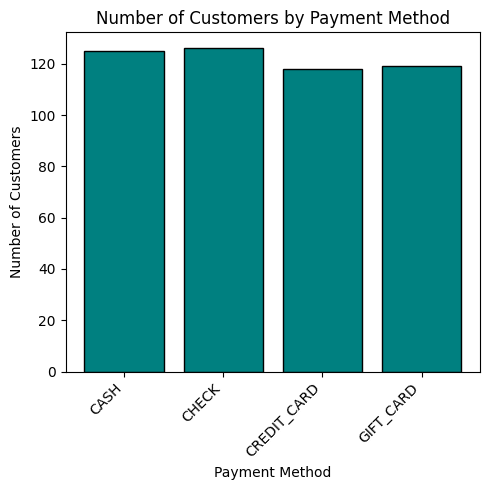

In [2276]:
payment_counts = orders.groupby('payment_method')['customer_id'].nunique().reset_index()
payment_counts.columns = ['payment_method', 'customer_count']
print(payment_counts)

plt.figure(figsize=(5, 5))
plt.bar(payment_counts['payment_method'], payment_counts['customer_count'], color='teal', edgecolor='black')
plt.title('Number of Customers by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### <span style="color:tomato; font-size:25px;"> 4a: Add total_price column to orders </span>

In [2277]:
rder_items_price = order_items.merge(
    items[['id', 'item_price']],
    left_on='item_id',
    right_on='id'
)

order_items_price['line_total'] = order_items_price['item_price'] * order_items_price['quantity']
order_totals = order_items_price.groupby('order_id')['line_total'].sum().reset_index()
order_totals.columns = ['order_id', 'total_price']

orders = orders.merge(order_totals, on='order_id', how='left')

print(orders[['order_id', 'total_price']].head(10))
print(f"\nOrders shape: {orders.shape}")

   order_id  total_price
0         1      8554.20
1         2     10148.58
2         3      6843.36
3         4       965.20
4         5     63944.94
5         6     12769.51
6         7      3454.82
7         8      2395.95
8         9          NaN
9        10     13781.14

Orders shape: (555, 8)


##### <span style="color:tomato; font-size:25px;"> 4b: Max, min and mean of total_price </span>

In [2278]:
orders_with_price = orders[orders['total_price'].notna()]

print(f"Max order total:  ${orders_with_price['total_price'].max():.2f}")
print(f"Min order total:  ${orders_with_price['total_price'].min():.2f}")
print(f"Mean order total: ${orders_with_price['total_price'].mean():.2f}")

Max order total:  $81267.68
Min order total:  $241.54
Mean order total: $14656.72


##### <span style="color:tomato; font-size:25px;"> 4c: Correlation between number of items and delivery time </span>

Correlation between number of items and delivery days: -0.0154


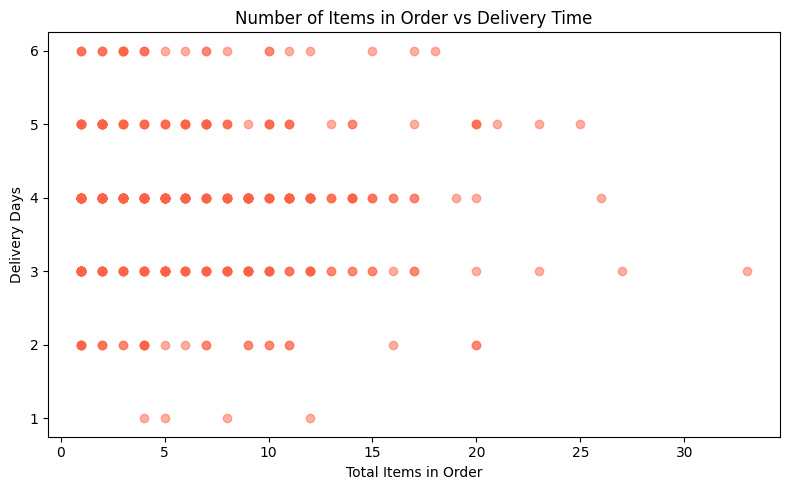


Conclusion: correlation close to 0 means no significant relationship
between number of items and delivery time.


In [2279]:
items_per_order = order_items.groupby('order_id')['quantity'].sum().reset_index()
items_per_order.columns = ['order_id', 'total_items']

correlation_df = items_per_order.merge(
    orders[['order_id', 'delivery_days']],
    on='order_id'
)

corr = correlation_df['total_items'].corr(correlation_df['delivery_days'])
print(f"Correlation between number of items and delivery days: {corr:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(correlation_df['total_items'], correlation_df['delivery_days'], alpha=0.5, color='tomato')
plt.title('Number of Items in Order vs Delivery Time')
plt.xlabel('Total Items in Order')
plt.ylabel('Delivery Days')
plt.tight_layout()
plt.show()

print("\nConclusion: correlation close to 0 means no significant relationship")
print("between number of items and delivery time.")

##### <span style="color:tomato; font-size:25px;"> 4d: Customers who never created any order </span>

In [2280]:
customers_with_orders = orders['customer_id'].unique()

customers_no_orders = customers[~customers['id'].isin(customers_with_orders)]

print(f"Number of customers who never created any order: {len(customers_no_orders)}")
print(customers_no_orders[['id', 'first_name', 'last_name']].head(10))

Number of customers who never created any order: 177
    id  first_name  last_name
1    2      Hammad  Brewerton
2    3     Terrell       Bris
5    6      Janine       Voak
6    7        Tori     Hawtin
7    8     Matthus   Gethouse
15  16      Joyann    Leehane
18  19     Gaylord    Swatten
20  21  Hyacinthie    Titchen
21  22       Timmy     Blowne
24  25     Aindrea   Addinall


##### <span style="color:tomato; font-size:25px;"> 4e: Top 5 items ordered the least </span>

In [2281]:
items_ordered = order_items.groupby('item_id')['quantity'].sum().reset_index()
items_ordered.columns = ['item_id', 'total_quantity_ordered']

items_ordered = items_ordered.merge(
    items[['id', 'item_name', 'item_brand']],
    left_on='item_id',
    right_on='id'
)

top5_least = items_ordered.sort_values('total_quantity_ordered').head(5)
print("Top 5 least ordered items:")
print(top5_least[['item_id', 'item_name', 'item_brand', 'total_quantity_ordered']])

Top 5 least ordered items:
    item_id            item_name item_brand  total_quantity_ordered
27     29.0               Webcam       Dell                      25
31     33.0      Surge Protector       ASUS                      27
19     21.0  External Hard Drive  Microsoft                      33
26     28.0          CCTV Camera       Sony                      34
5       6.0              Printer       Sony                      37


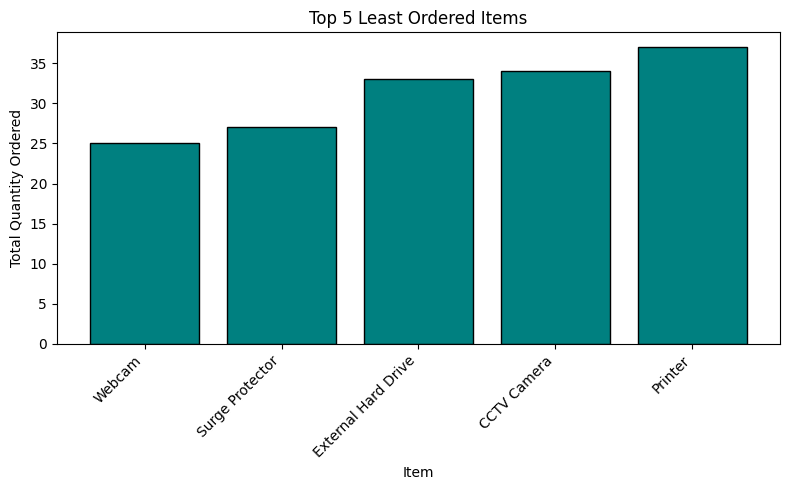

In [2282]:
plt.figure(figsize=(8, 5))
plt.bar(top5_least['item_name'], top5_least['total_quantity_ordered'], color='teal', edgecolor='black')
plt.title('Top 5 Least Ordered Items')
plt.xlabel('Item')
plt.ylabel('Total Quantity Ordered')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# <center> <span style="color:#08CB00; font-size:40px;"> Bonus </span>

##### <span style="color:red; font-size:25px;"> Bonus 1: USA marketing campaign effectiveness (August 2023) </span>

    month  order_count month_name
0       1           13    January
1       2            4   February
2       3            3      March
3       4            6      April
4       5            4        May
5       6            7       June
6       7            2       July
7       8            1     August
8       9            2  September
9      10            5    October
10     11            4   November
11     12            5   December

July (before campaign):       2.00
Avg Sep-Dec (after campaign): 4.00


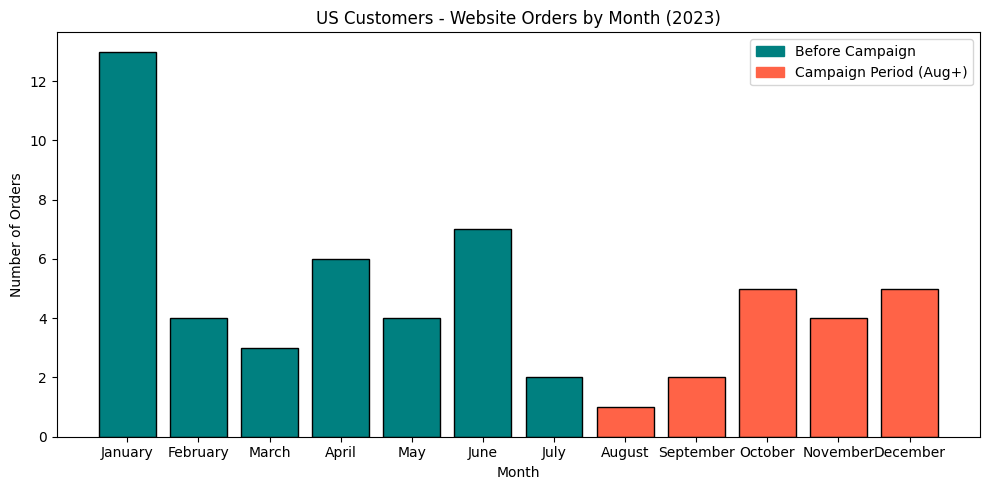

Conclusion: Campaign was EFFECTIVE - orders increased after August.


In [2283]:

# Convert order_date to datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['month'] = orders['order_date'].dt.month

# Get US customers ids
us_customers = customers[customers['nationallity'] == 'United States']['id'].tolist()

# Filter orders from US customers via WEBSITE only
us_website_orders = orders[
    (orders['customer_id'].isin(us_customers)) &
    (orders['order_source'] == 'WEBSITE')
]

# Count WEBSITE orders per month
us_monthly = us_website_orders.groupby('month')['order_id'].count().reset_index()
us_monthly.columns = ['month', 'order_count']
us_monthly['month_name'] = us_monthly['month'].map(month_names)
print(us_monthly)

# Compare July (before) vs Sep-Dec (after campaign)
july   = us_monthly[us_monthly['month'] == 7]['order_count'].values[0]
after  = us_monthly[us_monthly['month'] > 8]['order_count'].mean()

print(f"\nJuly (before campaign):       {july:.2f}")
print(f"Avg Sep-Dec (after campaign): {after:.2f}")

plt.figure(figsize=(10, 5))
bars = plt.bar(us_monthly['month_name'], us_monthly['order_count'], color='teal', edgecolor='black')
for bar, (_, row) in zip(bars, us_monthly.iterrows()):
    if row['month'] >= 8:
        bar.set_color('tomato')
        bar.set_edgecolor('black')

plt.title('US Customers - Website Orders by Month (2023)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color='teal', label='Before Campaign'),
    plt.Rectangle((0,0),1,1, color='tomato', label='Campaign Period (Aug+)')
])
plt.tight_layout()
plt.show()

if after > july:
    print("Conclusion: Campaign was EFFECTIVE - orders increased after August.")
else:
    print("Conclusion: Campaign was NOT effective - no increase in website orders.")

##### <span style="color:red; font-size:25px;"> Bonus 2: Gift card discount effectiveness (August 2023) </span>

    month  order_count month_name
0       1           12    January
1       2           13   February
2       3            6      March
3       4           13      April
4       5           11        May
5       6           16       June
6       7            5       July
7       8            7     August
8       9           11  September
9      10           15    October
10     11           14   November
11     12           12   December

Gift card orders in July:     5
Gift card orders in August:   7
Avg gift card orders Sep-Dec: 13.00


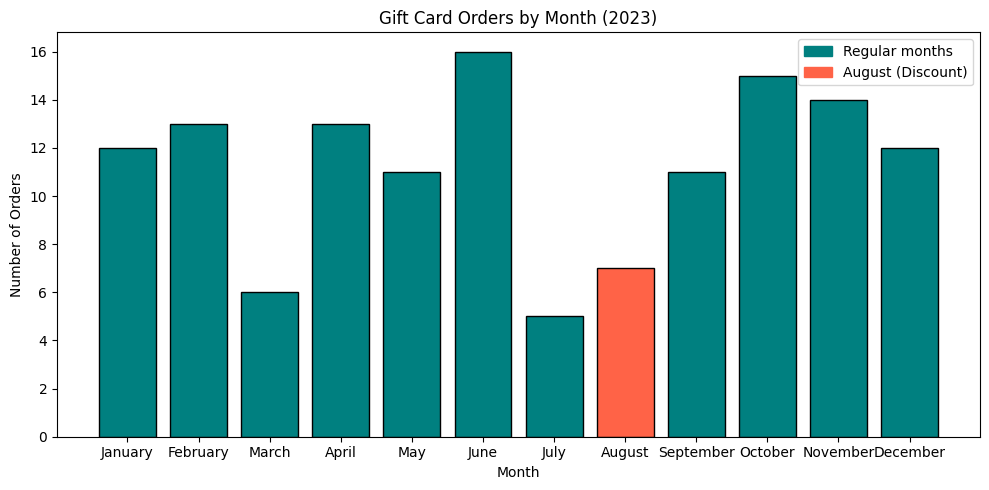


Conclusion: Discount was EFFECTIVE - gift card orders increased in August.


In [2284]:

# Count GIFT_CARD orders per month
gift_card_monthly = orders[orders['payment_method'] == 'GIFT_CARD'].groupby('month')['order_id'].count().reset_index()
gift_card_monthly.columns = ['month', 'order_count']
gift_card_monthly['month_name'] = gift_card_monthly['month'].map(month_names)
print(gift_card_monthly)

# Compare July vs August vs Sep-Dec
july_gc   = gift_card_monthly[gift_card_monthly['month'] == 7]['order_count'].values[0]
august_gc = gift_card_monthly[gift_card_monthly['month'] == 8]['order_count'].values[0]
after_gc  = gift_card_monthly[gift_card_monthly['month'] > 8]['order_count'].mean()

print(f"\nGift card orders in July:     {july_gc}")
print(f"Gift card orders in August:   {august_gc}")
print(f"Avg gift card orders Sep-Dec: {after_gc:.2f}")

plt.figure(figsize=(10, 5))
bars = plt.bar(gift_card_monthly['month_name'], gift_card_monthly['order_count'], color='teal', edgecolor='black')
for bar, (_, row) in zip(bars, gift_card_monthly.iterrows()):
    if row['month'] == 8:
        bar.set_color('tomato')
        bar.set_edgecolor('black')

plt.title('Gift Card Orders by Month (2023)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color='teal', label='Regular months'),
    plt.Rectangle((0,0),1,1, color='tomato', label='August (Discount)')
])
plt.tight_layout()
plt.show()

if august_gc > july_gc:
    print("\nConclusion: Discount was EFFECTIVE - gift card orders increased in August.")
else:
    print("\nConclusion: Discount was NOT effective - no increase in gift card orders.")